# 2 · Pretraining

The model gets written out in PyTorch here, organ by organ, exactly once. Then it trains on the whole corpus — about nine minutes and twenty-five cents on a rented RTX 4090 — and saves itself in Hugging Face format. Every later notebook loads that folder with library code and never looks inside again.

Two families of constants: what the model *is*, which freezes into the weights forever, and how it was *trained*, which is gone the moment training ends. The architecture is Llama's, shrunk until it fits in your head.

`VALIDATION_TOKENS` is a count, not a percentage, on purpose. Validation sizes to the precision of one measurement — a few million tokens pins the mean loss — while training benefits from every token you can feed it. A percentage would quietly donate training data to a measurement that doesn't improve.

In [1]:
import math
from contextlib import nullcontext
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tokenizers import Tokenizer
from tqdm import tqdm

# model
VOCAB_SIZE = 4096
CONTEXT = 512
D_MODEL = 256
N_LAYERS = 8
N_HEADS = 8
D_HEAD = D_MODEL // N_HEADS
D_FF = 768
ROPE_THETA = 10_000.0
NORM_EPS = 1e-6

# training
BATCH_SIZE = 64
STEPS = 16_500
WARMUP_STEPS = 500
PEAK_LR = 6e-4
MIN_LR = 6e-5
WEIGHT_DECAY = 0.1
GRAD_CLIP = 1.0
EVAL_EVERY = 500
EVAL_BATCHES = 32
VALIDATION_TOKENS = 5_000_000

# The written-out attention below is the reference; this routes the
# actual compute through PyTorch's fused kernel. Same math, measured.
FAST_ATTENTION = True

SEED = 20260830
ARTIFACTS = Path("artifacts")

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.set_float32_matmul_precision("high")
print(device)

cuda


The corpus becomes one flat array: every story tokenized, `<|endoftext|>` in front of each, concatenated into 554 million uint16s — the ribbon. Built once, cached, and a pure function of (corpus, tokenizer), so it can't go stale without our knowing why.

The validation slice comes off the end in one contiguous piece because stories are the unit of contamination: split at random positions and the model gets credit for completing stories whose beginnings it trained on.

In [2]:
tokenizer = Tokenizer.from_file(str(ARTIFACTS / "tokenizer.json"))
ENDOFTEXT = tokenizer.token_to_id("<|endoftext|>")

RIBBON_FILE = ARTIFACTS / "ribbon.npy"

if not RIBBON_FILE.exists():
    from datasets import load_dataset

    dataset = load_dataset("karpathy/tinystories-gpt4-clean", split="train")

    pieces = []
    for start in tqdm(range(0, len(dataset), 10_000)):
        batch = dataset[start : start + 10_000]["text"]
        for encoding in tokenizer.encode_batch(batch):
            pieces.append(np.array([ENDOFTEXT] + encoding.ids, dtype=np.uint16))
    np.save(RIBBON_FILE, np.concatenate(pieces))

ribbon = np.load(RIBBON_FILE)

train_ribbon = ribbon[:-VALIDATION_TOKENS]
valid_ribbon = ribbon[-VALIDATION_TOKENS:]

print(f"{len(ribbon):,} tokens ({len(train_ribbon):,} train, {len(valid_ribbon):,} validation)")

553,776,123 tokens (548,776,123 train, 5,000,000 validation)


`RMSNorm` divides each vector by its typical element size, then applies a learned per-channel gain. It's a class because that gain learns; the RoPE helpers are plain functions because nothing in them does — pure trigonometry, precomputed once.

RoPE marks position by *rotating* queries and keys. Rotation preserves length, and the dot product of two rotated vectors depends only on the difference of their angles — so attention scores depend on how far apart two tokens are, never on where they sit absolutely. Each pair of channels rotates at its own rate: fast hands resolve local distance, slow hands coarse position.

In [3]:
class RMSNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + NORM_EPS)
        return self.weight * (x / rms)


def rope_tables(context, d_head, theta):
    positions = torch.arange(context)
    frequencies = 1.0 / theta ** (torch.arange(0, d_head, 2) / d_head)
    angles = torch.outer(positions, frequencies)  # (context, d_head/2)
    angles = torch.cat([angles, angles], dim=-1)  # (context, d_head)
    return angles.cos(), angles.sin()


def rotate_half(x):
    left, right = x.chunk(2, dim=-1)
    return torch.cat([-right, left], dim=-1)


def apply_rope(x, cos, sin):
    return x * cos + rotate_half(x) * sin

Attention, written the slow way on purpose. The four projections are `nn.Linear` with `bias=False` — each is a matrix and nothing more; this model contains no additive terms anywhere. Queries and keys get RoPE; values don't, because position belongs to the *matching*, not the payload. Scores are QKᵀ/√d, the upper triangle is masked so no token sees the future, and softmax turns each row into a recipe. Then `weights @ v` does the listening: every position's output is a weighted average of the values it's allowed to see.

`FAST_ATTENTION` routes the actual compute through PyTorch's fused kernel — the production implementation, which never materializes the seq×seq score matrix at all. Same mathematics; the sanity cell below measures the difference. The written-out branch stays because seeing the matrix is the point of this chapter.

In [4]:
class Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.q_proj = nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.k_proj = nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.v_proj = nn.Linear(D_MODEL, D_MODEL, bias=False)
        self.o_proj = nn.Linear(D_MODEL, D_MODEL, bias=False)

    def forward(self, x, cos, sin):
        batch, seq, _ = x.shape

        # (batch, seq, d_model) -> (batch, n_heads, seq, d_head)
        q = self.q_proj(x).view(batch, seq, N_HEADS, D_HEAD).transpose(1, 2)
        k = self.k_proj(x).view(batch, seq, N_HEADS, D_HEAD).transpose(1, 2)
        v = self.v_proj(x).view(batch, seq, N_HEADS, D_HEAD).transpose(1, 2)

        q = apply_rope(q, cos, sin)
        k = apply_rope(k, cos, sin)

        if FAST_ATTENTION:
            out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        else:
            scores = q @ k.transpose(-2, -1) / math.sqrt(D_HEAD)  # (batch, heads, seq, seq)
            mask = torch.triu(torch.ones(seq, seq, dtype=torch.bool, device=x.device), diagonal=1)
            scores = scores.masked_fill(mask, float("-inf"))
            weights = scores.softmax(dim=-1)
            out = weights @ v  # (batch, heads, seq, d_head)
        out = out.transpose(1, 2).reshape(batch, seq, D_MODEL)
        return self.o_proj(out)

The MLP is SwiGLU: two projections up, one back down. `F.silu` is just the bend — the load-bearing character is the `*`, a learned gate that lets the network suppress a feature conditionally on everything else in the vector. `D_FF` is 3× the model width rather than the classic 4× because the third matrix is paid for out of the width.

The block wires one attention and one MLP around the residual stream, and the plus signs are the architecture: **x flows around the sublayers, not through them.** Each reads a normalized copy, computes off to the side, and adds its contribution back. Doing nothing is the default, and gradients get an express lane down the stack — the invention that made depth cheap. The norms sit inside the branches; the stream itself is never normalized.

In [5]:
class SwiGLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gate_proj = nn.Linear(D_MODEL, D_FF, bias=False)
        self.up_proj = nn.Linear(D_MODEL, D_FF, bias=False)
        self.down_proj = nn.Linear(D_FF, D_MODEL, bias=False)

    def forward(self, x):
        return self.down_proj(F.silu(self.gate_proj(x)) * self.up_proj(x))


class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_norm = RMSNorm(D_MODEL)
        self.attention = Attention()
        self.mlp_norm = RMSNorm(D_MODEL)
        self.mlp = SwiGLU()

    def forward(self, x, cos, sin):
        x = x + self.attention(self.input_norm(x), cos, sin)
        x = x + self.mlp(self.mlp_norm(x))
        return x

The whole animal: embedding, eight blocks, one final norm, and unembedding as the embedding's transpose — tied weights. Tying saves 13% of the parameters, and the two jobs are close enough to share: we raced tied against untied on parallel GPUs and they finished 0.005 nats apart. The tie is free.

The RoPE tables ride along as buffers: in the computation but not among the learners, and not saved to disk either. Learned things must be kept; derived things should be recomputed.

In [6]:
class LilTransformy(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, D_MODEL)
        self.blocks = nn.ModuleList(Block() for _ in range(N_LAYERS))
        self.final_norm = RMSNorm(D_MODEL)
        cos, sin = rope_tables(CONTEXT, D_HEAD, ROPE_THETA)
        self.register_buffer("cos", cos, persistent=False)
        self.register_buffer("sin", sin, persistent=False)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, tokens):
        seq = tokens.shape[1]
        cos, sin = self.cos[:seq], self.sin[:seq]
        x = self.embedding(tokens)
        for block in self.blocks:
            x = block(x, cos, sin)
        x = self.final_norm(x)
        return x @ self.embedding.weight.T  # tied embeddings


model = LilTransformy().to(device)
if device == "cuda":
    model = torch.compile(model)
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")

7,868,672 parameters


Three checks that cost nothing.

An untrained model must score ln(4096) — the loss of spreading bets evenly over the vocabulary. The first draft of this notebook printed 242 here, which is how a forgotten weight initialization announces itself.

Editing the last token must change no earlier logit — exactly zero, or the causal mask is broken.

And the two attention paths must agree. In fp32 they match to about a millionth; on CUDA, TF32 matmuls widen the gap to about 1e-3. Same arithmetic is not the same floating-point arithmetic.

In [7]:
tokens = torch.randint(0, VOCAB_SIZE, (2, CONTEXT), device=device)

with torch.no_grad():
    logits = model(tokens)
    loss = F.cross_entropy(logits[:, :-1].reshape(-1, VOCAB_SIZE), tokens[:, 1:].reshape(-1))
print(f"untrained loss {loss.item():.4f} vs ln({VOCAB_SIZE}) = {math.log(VOCAB_SIZE):.4f}")

tampered = tokens.clone()
tampered[:, -1] = (tampered[:, -1] + 1) % VOCAB_SIZE
with torch.no_grad():
    delta = (model(tampered)[:, :-1] - logits[:, :-1]).abs().max()
print(f"max change to earlier logits after editing the last token: {delta.item():.1e}")

# the two attention paths must be the same mathematics
with torch.no_grad():
    FAST_ATTENTION = False
    slow = model(tokens)
    FAST_ATTENTION = True
    gap = (model(tokens) - slow).abs().max()
print(f"fast vs written-out attention, max logit difference: {gap.item():.1e}")

untrained loss 8.3770 vs ln(4096) = 8.3178
max change to earlier logits after editing the last token: 0.0e+00
fast vs written-out attention, max logit difference: 9.8e-04


A batch is 64 random windows of the ribbon; `y` is `x` shifted one token left, so every position is simultaneously a question and the next position's answer — one window is 512 training examples. Validation is the same thing with gradients off, averaged over enough batches to steady the number.

In [8]:
def get_batch(source):
    starts = np.random.randint(0, len(source) - CONTEXT - 1, size=BATCH_SIZE)
    x = np.stack([source[i : i + CONTEXT] for i in starts]).astype(np.int64)
    y = np.stack([source[i + 1 : i + CONTEXT + 1] for i in starts]).astype(np.int64)
    return torch.from_numpy(x).to(device), torch.from_numpy(y).to(device)


@torch.no_grad()
def validation_loss():
    model.eval()
    total = 0.0
    for _ in range(EVAL_BATCHES):
        x, y = get_batch(valid_ribbon)
        total += F.cross_entropy(model(x).view(-1, VOCAB_SIZE), y.view(-1)).item()
    model.train()
    return total / EVAL_BATCHES

Warm up the learning rate, then cosine down to a floor. AdamW with the language-model betas, gradients clipped, matmuls in bfloat16. 16,500 steps × 32,768 tokens is one pass over the corpus.

Only one line in this loop changes the model: `optimizer.step()`. Everything else is measurement.

In [9]:
def learning_rate(step):
    if step < WARMUP_STEPS:
        return PEAK_LR * (step + 1) / WARMUP_STEPS
    progress = (step - WARMUP_STEPS) / (STEPS - WARMUP_STEPS)
    return MIN_LR + 0.5 * (PEAK_LR - MIN_LR) * (1 + math.cos(math.pi * progress))


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=PEAK_LR,
    betas=(0.9, 0.95),
    weight_decay=WEIGHT_DECAY,
    fused=(device == "cuda"),
)
amp = nullcontext() if device == "cpu" else torch.autocast(device, dtype=torch.bfloat16)

history = []
progress = tqdm(range(STEPS))
for step in progress:
    lr = learning_rate(step)
    for group in optimizer.param_groups:
        group["lr"] = lr

    x, y = get_batch(train_ribbon)
    with amp:
        loss = F.cross_entropy(model(x).view(-1, VOCAB_SIZE), y.view(-1))

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    optimizer.step()

    if step % 100 == 0:
        progress.set_postfix(loss=f"{loss.item():.4f}", lr=f"{lr:.1e}")
    if step % EVAL_EVERY == 0 or step == STEPS - 1:
        history.append((step, loss.item(), validation_loss()))

print(f"final validation loss {history[-1][2]:.4f}")

100%|██████████| 16500/16500 [08:53<00:00, 30.94it/s, loss=1.2707, lr=6.0e-05]

final validation loss 1.3005


Nearly all of the fall happens in the first thousand steps; the other fifteen thousand are polish. Train and validation move together the whole way — eight million parameters physically cannot memorize two gigabytes, so everything this model learned, it learned as structure.

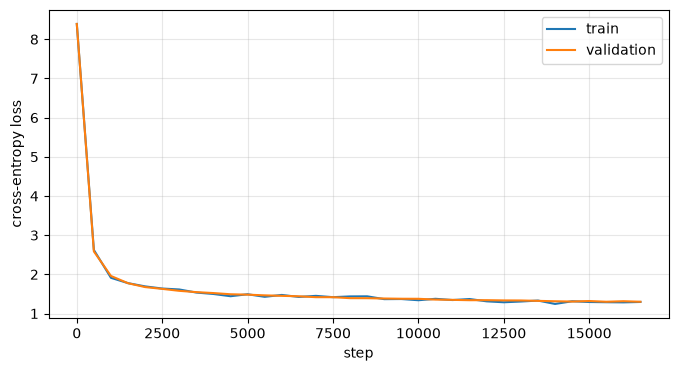

In [10]:
import matplotlib.pyplot as plt

steps, train, valid = zip(*history)
plt.figure(figsize=(8, 4))
plt.plot(steps, train, label="train")
plt.plot(steps, valid, label="validation")
plt.xlabel("step")
plt.ylabel("cross-entropy loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Same 74 tensors, two naming schemes. State-dict keys are attribute paths through the class tree, so our tensors wear our names; this dictionary translates each one to the name Hugging Face's Llama code expects. `load_state_dict` is strict — one wrong name or shape and it throws — which makes the translation self-checking. The `lm_head` line is double-entry bookkeeping for a tied tensor that exists once.

This cell is why the rest of the book gets to be short. A model is not a program; it's data. Data can be re-filed.

In [11]:
from transformers import LlamaConfig, LlamaForCausalLM

config = LlamaConfig(
    vocab_size=VOCAB_SIZE,
    hidden_size=D_MODEL,
    intermediate_size=D_FF,
    num_hidden_layers=N_LAYERS,
    num_attention_heads=N_HEADS,
    num_key_value_heads=N_HEADS,
    max_position_embeddings=CONTEXT,
    rms_norm_eps=NORM_EPS,
    rope_theta=ROPE_THETA,
    tie_word_embeddings=True,
    bos_token_id=ENDOFTEXT,
    eos_token_id=ENDOFTEXT,
    attention_bias=False,
    mlp_bias=False,
)

RENAMES = {
    "embedding.weight": "model.embed_tokens.weight",
    "final_norm.weight": "model.norm.weight",
}
for i in range(N_LAYERS):
    ours, theirs = f"blocks.{i}", f"model.layers.{i}"
    RENAMES |= {
        f"{ours}.input_norm.weight": f"{theirs}.input_layernorm.weight",
        f"{ours}.mlp_norm.weight": f"{theirs}.post_attention_layernorm.weight",
        f"{ours}.attention.q_proj.weight": f"{theirs}.self_attn.q_proj.weight",
        f"{ours}.attention.k_proj.weight": f"{theirs}.self_attn.k_proj.weight",
        f"{ours}.attention.v_proj.weight": f"{theirs}.self_attn.v_proj.weight",
        f"{ours}.attention.o_proj.weight": f"{theirs}.self_attn.o_proj.weight",
        f"{ours}.mlp.gate_proj.weight": f"{theirs}.mlp.gate_proj.weight",
        f"{ours}.mlp.up_proj.weight": f"{theirs}.mlp.up_proj.weight",
        f"{ours}.mlp.down_proj.weight": f"{theirs}.mlp.down_proj.weight",
    }

# torch.compile wraps the model and prefixes every state_dict key
# with "_orig_mod." — strip it so the rename table matches.
state = {
    RENAMES[k.removeprefix("_orig_mod.")]: v.cpu()
    for k, v in model.state_dict().items()
}
state["lm_head.weight"] = state["model.embed_tokens.weight"]

export = LlamaForCausalLM(config)
export.load_state_dict(state)

MODEL_DIR = ARTIFACTS / "lil-transformy-2"
export.save_pretrained(MODEL_DIR)
print(sorted(p.name for p in MODEL_DIR.iterdir()))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['config.json', 'generation_config.json', 'model.safetensors']


The payoff. Prompted with the lone separator token, the model writes a story — beginning, middle, end — and stops by itself, by predicting `<|endoftext|>`, exactly the way it learned stories end.

Sampling is temperature 0.7 with top-p 0.95, which keeps only the smallest set of candidates holding 95% of the probability — strict where the model is confident, loose where it's torn. At eight million parameters the sampler is audibly part of the writer.

In [12]:
story_model = LlamaForCausalLM.from_pretrained(MODEL_DIR).to(device).eval()


def tell_me_a_story(prompt_text=""):
    ids = [ENDOFTEXT] + tokenizer.encode(prompt_text).ids
    prompt = torch.tensor([ids], device=device)
    output = story_model.generate(
        prompt,
        max_new_tokens=400,
        do_sample=True,
        temperature=0.7,
        top_p=0.95,
        eos_token_id=ENDOFTEXT,
        pad_token_id=ENDOFTEXT,
    )
    return tokenizer.decode(output[0].tolist())


print(tell_me_a_story())
print("\n" + "=" * 70 + "\n")
print(tell_me_a_story("Once upon a time, there was a rhinoceros named"))

Loading weights:   0%|          | 0/74 [00:00<?, ?it/s]

Once upon a time, there was a little ant. The ant was weak, but he was strong. He lived in a big beehive with his family in the grass. The ant liked to help his family.
One day, the ant found a big leaf. He had an idea. He wanted to push the leaf with his nose. He thought it would make a great big work. But he was too weak to push the leaf.
Then, something unexpected happened. A big bird flew down and tried to help the ant. The bird pulled the leaf from the ant's mouth. The ant was so happy! The bird thanked the ant and they became friends. The ants helped the ant to build a big, soft nest.
In the end, the weak ant was strong and strong. He learned that being strong and kind can make friends. And the ant learned that even small friends can be strong and strong.


Once upon a time, there was a rhinoceros named Remy. Remy was a big rhinoceros who lived in a forest. He loved to play with his friends, the birds and the rabbits.
One day, Remy saw a distant hill. He thought it would be fun t